# Credit Risk Scoring — Data Understanding & EDA

This notebook describes the verified `data/raw/cs-training.csv` and identifies decisions required before preprocessing and splitting. The local `train.csv` / `test.csv` and Kaggle competition test file are not used.

**Scope:** descriptive analysis only. No imputation, record removal, capping, resampling, scaling, encoding, predictive feature creation, model fitting, or dataset splitting is performed. Temporary bins and masks are analysis labels only; they are not added to the predictive dataset.

**Reproducibility:** select this project's `.venv` Python kernel and run all cells in order. Paths resolve from either the repository root or the notebook directory. Dependencies are declared in `requirements.txt`; `ipykernel` provides notebook execution. Only three portfolio figures are saved to `reports/figures/`.

**Evaluation limitation:** this requested EDA examines the entire labeled dataset. A future holdout drawn from it will not be completely untouched by analyst inspection. Freeze decisions before evaluating models and disclose this limitation; an independent, uninspected labeled dataset would support a stronger final evaluation.


In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

get_ipython().run_line_magic('matplotlib', 'inline')
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/raw/cs-training.csv').is_file()
             and (p / 'requirements.txt').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run from the project root or a directory beneath it.')
if Path(sys.prefix).resolve() != (ROOT / '.venv').resolve():
    raise RuntimeError('Select the project .venv interpreter before running this notebook.')

DATA_PATH = ROOT / 'data/raw/cs-training.csv'
DICTIONARY_PATH = ROOT / 'data/raw/Data Dictionary.xls'
FIGURES_DIR = ROOT / 'reports/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPECTED_RAW_SHA256 = '1bd46da486a5708c58c7b01a034fae2a13b327f6f7b62ea7ba4fe3b5824b24ac'
EXPECTED_DICTIONARY_SHA256 = 'cd0ca41078790a46cc313769eafdc5dc7132a0188c80e01d6f3b35b24a290942'

def file_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

raw_hash_before = file_sha256(DATA_PATH)
dictionary_hash_before = file_sha256(DICTIONARY_PATH)
assert raw_hash_before == EXPECTED_RAW_SHA256, 'Dataset differs from the verified candidate.'
assert dictionary_hash_before == EXPECTED_DICTIONARY_SHA256, 'Dictionary differs from the verified source.'
versions = {'Python': platform.python_version(), **{
    name: importlib.metadata.version(name)
    for name in ['pandas', 'numpy', 'matplotlib', 'xlrd', 'ipykernel']}}
display(pd.Series(versions, name='Version').to_frame())
print('Dataset SHA-256:', raw_hash_before)

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlesize': 11, 'axes.labelsize': 10,
                     'font.size': 10, 'axes.axisbelow': True})
BLUE, ORANGE = '#2563a6', '#d87825'
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 100)

def show_table(table):
    # Render every row; presentation formatting never changes stored values.
    display(HTML(table.to_html(float_format=lambda value: f'{value:.4f}', na_rep='Missing', escape=True)))

def frame_fingerprint(frame):
    return (tuple(frame.columns), tuple(map(str, frame.dtypes)),
            hashlib.sha256(pd.util.hash_pandas_object(frame, index=True).values.tobytes()).hexdigest())


,Version
Python,3.13.14
pandas,3.0.6
numpy,2.5.3
matplotlib,3.11.2
xlrd,2.0.2
ipykernel,7.4.0


Dataset SHA-256: 1bd46da486a5708c58c7b01a034fae2a13b327f6f7b62ea7ba4fe3b5824b24ac


## 1. Dataset and official definitions

The dictionary is read directly from the supplied `.xls` file. Its descriptions are the official-definition reference for this analysis; interpretive comments below are separate from those descriptions.


In [2]:
dictionary = pd.read_excel(DICTIONARY_PATH, header=1)
show_table(dictionary)
TARGET = 'SeriousDlqin2yrs'
INDEX_COL = 'Unnamed: 0'
declared_columns = dictionary['Variable Name'].dropna().tolist()
FEATURES = [c for c in declared_columns if c != TARGET]
raw = pd.read_csv(DATA_PATH, float_precision='round_trip')
raw_fingerprint_before = frame_fingerprint(raw)

assert raw.shape == (150000, 12)
assert len(FEATURES) == 10
assert raw.columns.tolist() == [INDEX_COL, *declared_columns]
assert raw[TARGET].notna().all() and set(raw[TARGET].unique()) == {0, 1}
index_checks = pd.Series({
    'unique': raw[INDEX_COL].is_unique,
    'sequential_1_to_150000': np.array_equal(raw[INDEX_COL], np.arange(1, len(raw) + 1)),
    'absent_from_dictionary': INDEX_COL not in declared_columns,
    'minimum': raw[INDEX_COL].min(), 'maximum': raw[INDEX_COL].max()}, name='Result')
assert index_checks.iloc[:3].all()
print('Shape:', raw.shape, '| Predictive features:', len(FEATURES), '| Target:', TARGET)
display(raw.dtypes.rename('Pandas dtype').to_frame())
display(raw.head(5))
display(index_checks.to_frame())

# A separate working copy excludes the index only. All observations are retained.
eda = raw.loc[:, declared_columns].copy(deep=True)
eda_fingerprint_before = frame_fingerprint(eda)
X = eda.loc[:, FEATURES]
y = eda[TARGET]


,Variable Name,Description,Type
0,SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
2,age,Age of borrower in years,integer
3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
4,DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
5,MonthlyIncome,Monthly income,real
6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


Shape: (150000, 12) | Predictive features: 10 | Target: SeriousDlqin2yrs


,Pandas dtype
Unnamed: 0,int64
SeriousDlqin2yrs,int64
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


,Result
unique,True
sequential_1_to_150000,True
absent_from_dictionary,True
minimum,1
maximum,150000


**Observation:** `Unnamed: 0` is unique, sequential from 1 to 150000, and absent from the dictionary.

**Interpretation:** it is an index-like column, not a documented borrower identifier. **Unnamed: 0 is an index-like column and will not be used as a predictive feature.** It is excluded only from the separate EDA working copy; the raw CSV and `raw` DataFrame remain intact.

## 2. Target and class balance

`1` denotes a borrower who experienced serious delinquency (90 days past due or worse) in the prediction horizon; `0` means that event was not observed. A zero does not rule out less severe late payments. The dictionary describes the event and uses type `Y/N`; the two-year prediction horizon comes from the competition context and target name. This is not a bankruptcy label.

Reference: [Give Me Some Credit competition](https://www.kaggle.com/competitions/GiveMeSomeCredit). All rates below are descriptive associations, not causal effects or model results.


,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.3160
1,10026,6.6840


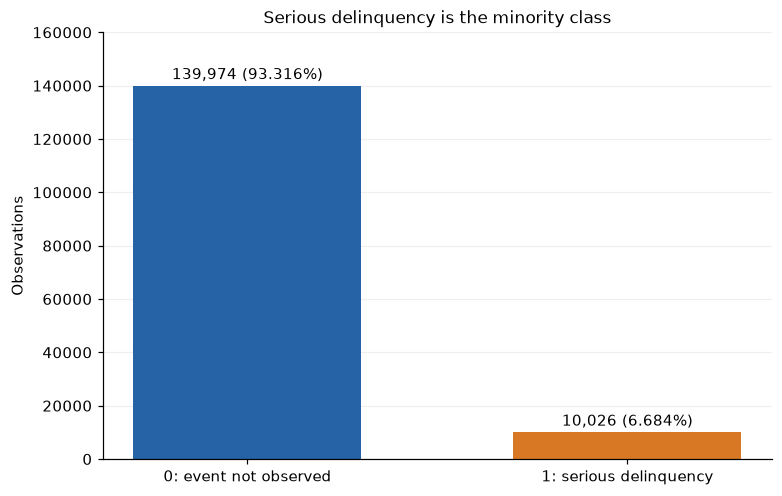

In [3]:
target_summary = y.value_counts().sort_index().rename('Count').to_frame()
target_summary['Percentage'] = target_summary['Count'] / len(eda) * 100
show_table(target_summary)
fig, ax = plt.subplots(figsize=(7, 4.4), layout='constrained')
bars = ax.bar(['0: event not observed', '1: serious delinquency'],
              target_summary['Count'], color=[BLUE, ORANGE], width=0.6)
for bar, count, pct in zip(bars, target_summary['Count'], target_summary['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, count + 2500,
            f'{count:,} ({pct:.3f}%)', ha='center')
ax.set(title='Serious delinquency is the minority class', ylabel='Observations', ylim=(0, 160000))
ax.grid(axis='y', alpha=.2)
fig.savefig(FIGURES_DIR / 'target_distribution.png', bbox_inches='tight')
plt.show()


**Interpretation:** the minority event rate makes accuracy alone a poor future evaluation summary. Stratification and suitable discrimination/calibration metrics will need to be considered later. No class balancing is performed here.

## 3. Missing values and target association

Missing and present groups are compared with their sample sizes. These comparisons are unadjusted and may reflect other population differences; they do not establish causality. No values are filled.


,Missing Count,Missing Percentage
Feature,,
MonthlyIncome,29731,19.8207
NumberOfDependents,3924,2.6160
age,0,0.0000
RevolvingUtilizationOfUnsecuredLines,0,0.0000
DebtRatio,0,0.0000
NumberOfTime30-59DaysPastDueNotWorse,0,0.0000
NumberOfOpenCreditLinesAndLoans,0,0.0000
NumberOfTimes90DaysLate,0,0.0000
NumberRealEstateLoansOrLines,0,0.0000


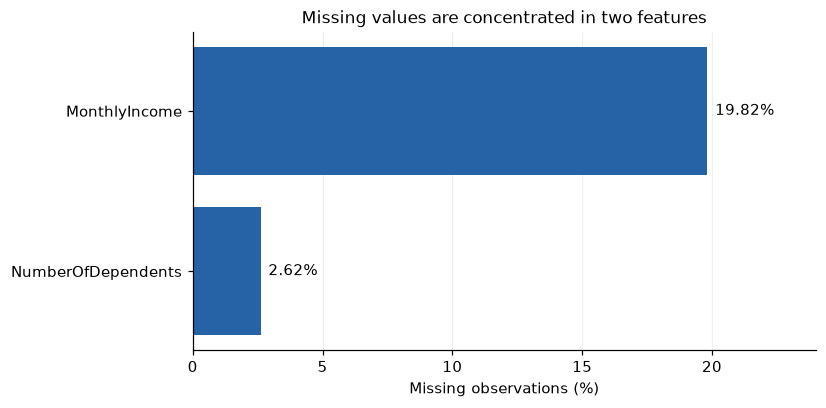

In [4]:
missing_summary = X.isna().sum().rename('Missing Count').to_frame()
missing_summary['Missing Percentage'] = missing_summary['Missing Count'] / len(X) * 100
missing_summary.index.name = 'Feature'
missing_summary = missing_summary.sort_values('Missing Count', ascending=False)
show_table(missing_summary)

def mask_summary(masks):
    rows = []
    for label, mask in masks.items():
        events = y.loc[mask]
        rows.append({'Group': label, 'Count': len(events), 'Events': int(events.sum()),
                     'Target rate (%)': events.mean() * 100 if len(events) else np.nan})
    return pd.DataFrame(rows).set_index('Group')

missing_association = pd.concat({col: mask_summary({
    'Missing': X[col].isna(), 'Present': X[col].notna()})
    for col in ['MonthlyIncome', 'NumberOfDependents']}, names=['Feature'])
show_table(missing_association)
fig, ax = plt.subplots(figsize=(7.4, 3.6), layout='constrained')
missing_nonzero = missing_summary.loc[missing_summary['Missing Count'] > 0]
bars = ax.barh(missing_nonzero.index, missing_nonzero['Missing Percentage'], color=BLUE)
for bar, pct in zip(bars, missing_nonzero['Missing Percentage']):
    ax.text(pct + .3, bar.get_y() + bar.get_height()/2, f'{pct:.2f}%', va='center')
ax.set(title='Missing values are concentrated in two features', xlabel='Missing observations (%)', xlim=(0, 24))
ax.invert_yaxis()
ax.grid(axis='x', alpha=.2)
fig.savefig(FIGURES_DIR / 'missing_values.png', bbox_inches='tight')
plt.show()


## 4. Duplicate investigation

Two definitions are evaluated separately: **A**, identical features and target; **B**, identical ten-feature vectors regardless of target. Missing values at corresponding positions count as equal (`dropna=False` in grouping). Counts of excess duplicate rows exclude the first occurrence; group membership counts include every observation in a repeated group.


In [5]:
exact_group_sizes = eda.groupby(declared_columns, dropna=False, sort=False).size()
feature_groups = eda.groupby(FEATURES, dropna=False, sort=False)[TARGET].agg(
    observations='size', positives='sum', distinct_targets='nunique')
repeated_exact = exact_group_sizes.loc[exact_group_sizes > 1]
repeated_features = feature_groups.loc[feature_groups['observations'] > 1]
inconsistent_groups = repeated_features.loc[repeated_features['distinct_targets'] > 1]
duplicate_summary = pd.DataFrame([
    {'Definition': 'A: same features + target', 'Excess duplicate rows': int(eda.duplicated().sum()),
     'Duplicate groups': len(repeated_exact), 'Observations in duplicate groups': int(repeated_exact.sum()),
     'Largest group': int(exact_group_sizes.max())},
    {'Definition': 'B: same ten features', 'Excess duplicate rows': int(X.duplicated().sum()),
     'Duplicate groups': len(repeated_features), 'Observations in duplicate groups': int(repeated_features['observations'].sum()),
     'Largest group': int(feature_groups['observations'].max())}
]).set_index('Definition')
assert duplicate_summary.iloc[0]['Excess duplicate rows'] == 609
assert duplicate_summary.iloc[1]['Excess duplicate rows'] == 646
show_table(duplicate_summary)
print('Exact duplicates including raw index:', int(raw.duplicated().sum()))
print('Inconsistent-target feature groups:', len(inconsistent_groups))
print('Observations in inconsistent-target groups:', int(inconsistent_groups['observations'].sum()))
print('Example inconsistent groups: all ten features, counts and positive labels')
show_table(inconsistent_groups.sort_values('observations', ascending=False).head(5).reset_index())


,Excess duplicate rows,Duplicate groups,Observations in duplicate groups,Largest group
Definition,,,,
A: same features + target,609,351,960,12
B: same ten features,646,354,1000,12


Exact duplicates including raw index: 0
Inconsistent-target feature groups: 37
Observations in inconsistent-target groups: 145
Example inconsistent groups: all ten features, counts and positive labels


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,observations,positives,distinct_targets
0,1.0000,40,0,0.0000,Missing,0,0,0,0,0.0000,8,3,2
1,1.0000,37,0,0.0000,Missing,0,0,0,0,0.0000,7,1,2
2,1.0000,59,0,0.0000,Missing,0,0,0,0,0.0000,7,1,2
3,1.0000,31,0,0.0000,Missing,0,0,0,0,0.0000,6,2,2
4,1.0000,63,0,0.0000,Missing,1,0,0,0,0.0000,6,1,2


**Interpretation:** a random row split may put identical feature vectors in both training and evaluation sets, increasing dependence and potentially making evaluation optimistic. Identical vectors are **not evidence that records belong to the same borrower**: the dataset has no documented borrower ID, and coarse/count features can legitimately coincide. Conflicting targets also prevent interpreting every duplicate as an accidental copy.

**Recommendation, not an action:** investigate provenance and compare a predeclared stratified row split with a feature-group-disjoint split or sensitivity analysis. If feature grouping is chosen, group using the ten original features and a documented missing/precision policy, never the target; check class proportions. No records are removed and no split is created.

## 5. Numerical distributions

The full descriptive table includes all ten predictive features. Histograms use the original values. Skewed monetary/ratio features use logarithmically spaced bins and a symmetric-log **axis** to retain zero values; this changes the display, not the stored data. Missing observations are excluded only from the corresponding histogram and are counted in its panel. Unequal-width bins display counts, not probability densities. Logarithmic count axes make sparse tails visible.


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0484,249.7554,0.0000,0.0000,0.0000,0.0299,0.1542,0.5590,1.0000,1.0930,50708.0000
age,150000.0000,52.2952,14.7719,0.0000,24.0000,29.0000,41.0000,52.0000,63.0000,78.0000,87.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,150000.0000,0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,98.0000
DebtRatio,150000.0000,353.0051,2037.8185,0.0000,0.0000,0.0043,0.1751,0.3665,0.8683,2449.0000,4979.0400,329664.0000
MonthlyIncome,120269.0000,6670.2212,14384.6742,0.0000,0.0000,1300.0000,3400.0000,5400.0000,8249.0000,14587.6000,25000.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4528,5.1460,0.0000,0.0000,2.0000,5.0000,8.0000,11.0000,18.0000,24.0000,58.0000
NumberOfTimes90DaysLate,150000.0000,0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,98.0000
NumberRealEstateLoansOrLines,150000.0000,1.0182,1.1298,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,4.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,150000.0000,0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,98.0000
NumberOfDependents,146076.0000,0.7572,1.1151,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,20.0000


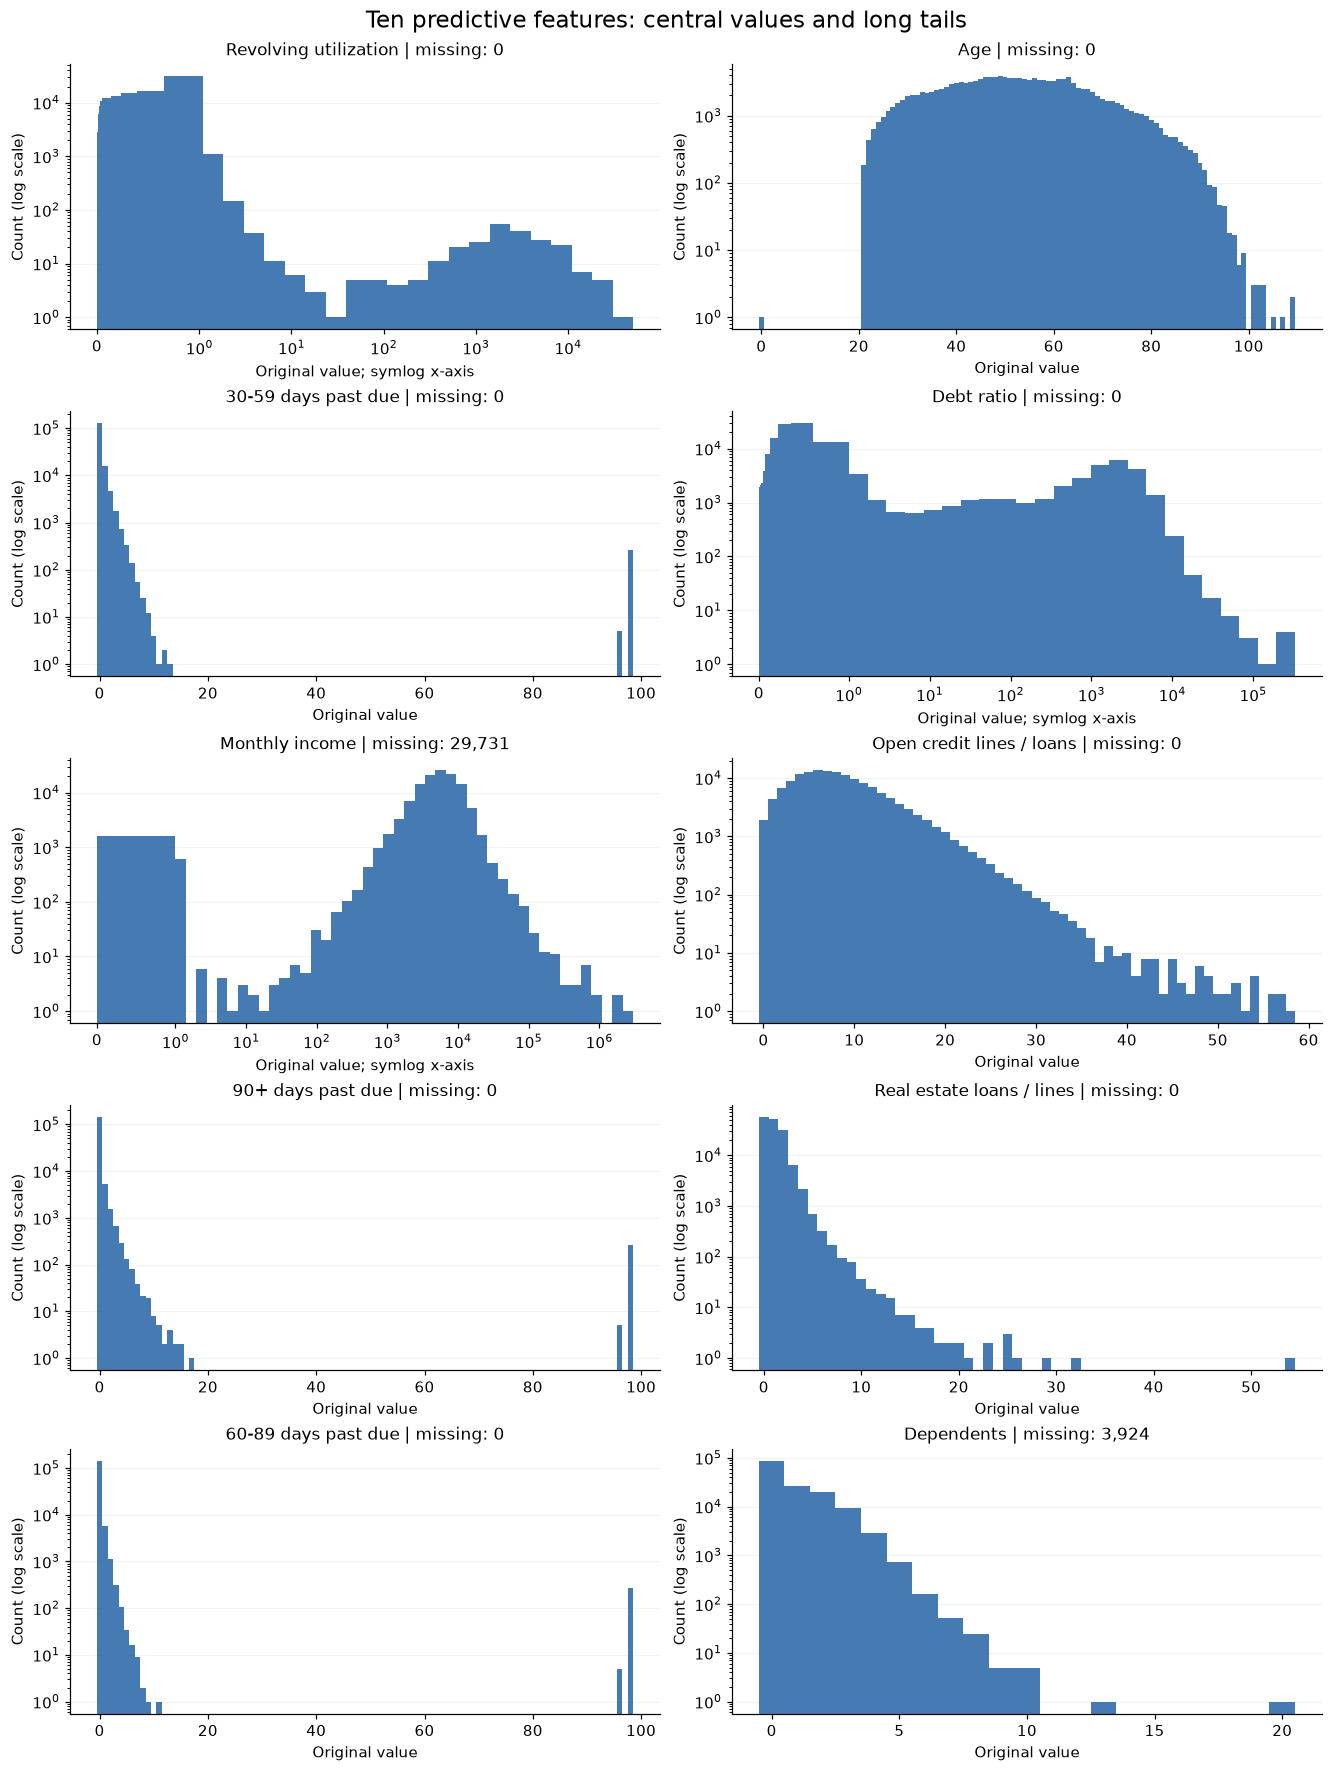

In [6]:
numeric_summary = X.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
show_table(numeric_summary)
labels = {
    'RevolvingUtilizationOfUnsecuredLines': 'Revolving utilization', 'age': 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse': '30-59 days past due', 'DebtRatio': 'Debt ratio',
    'MonthlyIncome': 'Monthly income', 'NumberOfOpenCreditLinesAndLoans': 'Open credit lines / loans',
    'NumberOfTimes90DaysLate': '90+ days past due', 'NumberRealEstateLoansOrLines': 'Real estate loans / lines',
    'NumberOfTime60-89DaysPastDueNotWorse': '60-89 days past due', 'NumberOfDependents': 'Dependents'}
fig, axes = plt.subplots(5, 2, figsize=(12, 16), layout='constrained')
for ax, col in zip(axes.flat, FEATURES):
    values = X[col].dropna()
    if col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
        positive = values.loc[values > 0]
        bins = np.r_[0, np.geomspace(positive.min(), values.max(), 45)]
        ax.hist(values, bins=bins, color=BLUE, alpha=.85)
        ax.set_xscale('symlog', linthresh=1)
        axis_note = 'Original value; symlog x-axis'
    else:
        ax.hist(values, bins=np.arange(values.min() - .5, values.max() + 1.5), color=BLUE, alpha=.85)
        axis_note = 'Original value'
    ax.set_yscale('log')
    ax.set(title=f'{labels[col]} | missing: {X[col].isna().sum():,}', xlabel=axis_note, ylabel='Count (log scale)')
    ax.grid(axis='y', alpha=.15)
fig.suptitle('Ten predictive features: central values and long tails', fontsize=15)
plt.show()


## 6. Age investigation

The two low-age checks below overlap (`age = 0` is also `<18`). They are diagnostic counts and must not be added together. High age alone is not proof of an error.


In [7]:
age_summary = mask_summary({'age = 0': X['age'].eq(0), 'age < 18': X['age'].lt(18),
                            '18 <= age <= 100': X['age'].between(18, 100), 'age > 100': X['age'].gt(100)})
age_summary['Target 0 count'] = age_summary['Count'] - age_summary['Events']
print('Age minimum / maximum:', X['age'].min(), X['age'].max())
show_table(age_summary)


Age minimum / maximum: 0 109


,Count,Events,Target rate (%),Target 0 count
Group,,,,
age = 0,1,0,0.0000,1
age < 18,1,0,0.0000,1
18 <= age <= 100,149986,10025,6.6840,139961
age > 100,13,1,7.6923,12


**Recommendation:** investigate the zero-age record as potentially invalid; treating it as missing is a candidate future policy, not a change made here. Retain very old ages provisionally unless source evidence establishes invalidity. Avoid deleting rare age groups based only on their observed target rate, especially when group sizes are tiny.

## 7. Delinquency variables: 96 and 98

The dictionary specifies counts but does not explain `96` or `98`. They are **Special values requiring investigation.** Do not assume they are missing codes or error codes. The 30-59 and 60-89 day definitions specify the previous two years; the 90+ day definition does not explicitly state a lookback window.


In [8]:
DELINQUENCY = ['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']
special_summary = pd.concat({col: mask_summary({
    'value = 96': X[col].eq(96), 'value = 98': X[col].eq(98),
    'other values': ~X[col].isin([96, 98])}) for col in DELINQUENCY}, names=['Feature'])
show_table(special_summary)
high_counts = pd.concat({col: X.loc[X[col] >= 10, col].value_counts().sort_index()
                        for col in DELINQUENCY}, names=['Feature', 'Value']).rename('Count').to_frame()
print('High-value counts (threshold >=10, for inspection only):')
show_table(high_counts)
any_special = X[DELINQUENCY].isin([96, 98]).any(axis=1)
all_special = X[DELINQUENCY].isin([96, 98]).all(axis=1)
print('Any column is 96/98:', int(any_special.sum()), '| All three are 96/98:', int(all_special.sum()))
special_patterns = eda.loc[any_special].groupby(DELINQUENCY, dropna=False)[TARGET].agg(
    Count='size', Events='sum', TargetRate='mean')
show_table(special_patterns.rename(columns={'TargetRate': 'Target rate (fraction)'}))


High-value counts (threshold >=10, for inspection only):


Any column is 96/98: 269 | All three are 96/98: 269


,,,Count,Events,Target rate (fraction)
NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,,,
96,96,96,5,4,0.8000
98,98,98,264,143,0.5417


**Interpretation:** synchronized extreme values can dominate correlations and may reflect a shared recording convention, but the available documentation does not establish their origin. Preserve them until a documented treatment and sensitivity analysis are approved.

## 8. Revolving utilization

Official definition: balance on credit cards and personal lines of credit, excluding real estate and installment debt, divided by the sum of credit limits. The ratio is already supplied; its raw numerator and denominator are unavailable. A ratio above one may reflect over-limit exposure and is not automatically invalid. No `credit_used / credit_limit` feature is constructed.

Range boundaries below are fixed descriptive choices, not thresholds optimized against the target. Small groups require caution.


In [9]:
def threshold_summary(col):
    return mask_summary({'<= 1': X[col].le(1), '> 1': X[col].gt(1),
                         '> 5': X[col].gt(5), '> 10': X[col].gt(10)})

def binned_target(col, edges, names):
    bins = pd.cut(X[col], bins=edges, labels=names, include_lowest=True)
    result = y.groupby(bins, observed=False).agg(Count='size', Events='sum', Rate='mean')
    return result.rename(columns={'Rate': 'Target rate (%)'}).assign(**{
        'Target rate (%)': result['Rate'] * 100})

ratio_edges = [-np.inf, 0, .25, .5, 1, 5, 10, np.inf]
ratio_labels = ['<=0', '(0, .25]', '(.25, .5]', '(.5, 1]', '(1, 5]', '(5, 10]', '>10']
util_col = 'RevolvingUtilizationOfUnsecuredLines'
print('Threshold checks overlap; do not sum these counts:')
show_table(threshold_summary(util_col))
show_table(numeric_summary.loc[[util_col]])
utilization_rates = binned_target(util_col, ratio_edges, ratio_labels)
show_table(utilization_rates)
print('Ten largest original utilization values:')
display(X[util_col].nlargest(10).rename('Utilization'))


Threshold checks overlap; do not sum these counts:


,Count,Events,Target rate (%)
Group,,,
<= 1,146679,8789,5.9920
> 1,3321,1237,37.2478
> 5,254,20,7.8740
> 10,241,17,7.0539


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0484,249.7554,0.0000,0.0000,0.0000,0.0299,0.1542,0.5590,1.0000,1.0930,50708.0000


,Count,Events,Target rate (%)
RevolvingUtilizationOfUnsecuredLines,,,
<=0,10878,320,2.9417
"(0, .25]",76779,1553,2.0227
"(.25, .5]",21055,1114,5.2909
"(.5, 1]",37967,5802,15.2817
"(1, 5]",3067,1217,39.6805
"(5, 10]",13,3,23.0769
>10,241,17,7.0539


Ten largest original utilization values:


85489     50708.0
31414     29110.0
16956     22198.0
149160    22000.0
149279    20514.0
117315    18300.0
21978     17441.0
124533    13930.0
72592     13498.0
71705     13400.0
Name: Utilization, dtype: float64

## 9. Debt ratio and income availability

Official numerator: **monthly debt payments + alimony + living costs**. Denominator: **monthly gross income**. This is not total outstanding debt divided by income, and multiplying it by income does not establish a total debt balance.

The requested `income present` comparison includes zero income. An additional mutually exclusive missing / zero / positive table avoids double-counting when interpreting the groups.


,Count,Events,Target rate (%)
Group,,,
<= 1,114863,7735,6.7341
> 1,35137,2291,6.5202
> 5,29646,1642,5.5387
> 10,28877,1609,5.5719


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
DebtRatio,150000.0000,353.0051,2037.8185,0.0000,0.0000,0.0043,0.1751,0.3665,0.8683,2449.0000,4979.0400,329664.0000


,Count,Events,Target rate (%)
DebtRatio,,,
<=0,4113,340,8.2665
"(0, .25]",48248,2786,5.7743
"(.25, .5]",41347,2529,6.1165
"(.5, 1]",21155,2080,9.8322
"(1, 5]",5491,649,11.8193
"(5, 10]",769,33,4.2913
>10,28877,1609,5.5719


,count,mean,std,min,50%,95%,99%,max
Income missing,29731.0000,1673.3966,4248.3729,0.0000,1159.0000,4902.5000,8084.5000,329664.0000
Income present (including zero),120269.0000,26.5988,424.4465,0.0000,0.2960,1.1288,661.8200,61106.5000
Income = 0,1634.0000,1573.5673,2818.0159,0.0000,930.0000,4896.7000,10504.0500,60212.0000


,Count,Median DebtRatio,P99 DebtRatio,Maximum DebtRatio,DebtRatio > 1 count,DebtRatio > 5 count,DebtRatio > 10 count,DebtRatio > 10 (%)
Income group,,,,,,,,
Missing,29731,1159.0000,8084.5000,329664.0000,27904,27294,26771,90.0441
Zero,1634,930.0000,10504.0500,60212.0000,1521,1490,1447,88.5557
Positive,118635,0.2925,2.9944,61106.5000,5712,862,659,0.5555


Ten largest original DebtRatio values:


60152     329664.0
36600     326442.0
127047    307001.0
58900     220516.0
4854      168835.0
7513      110952.0
103041    106885.0
69845     101320.0
66785      61907.0
53682      61106.5
Name: DebtRatio, dtype: float64

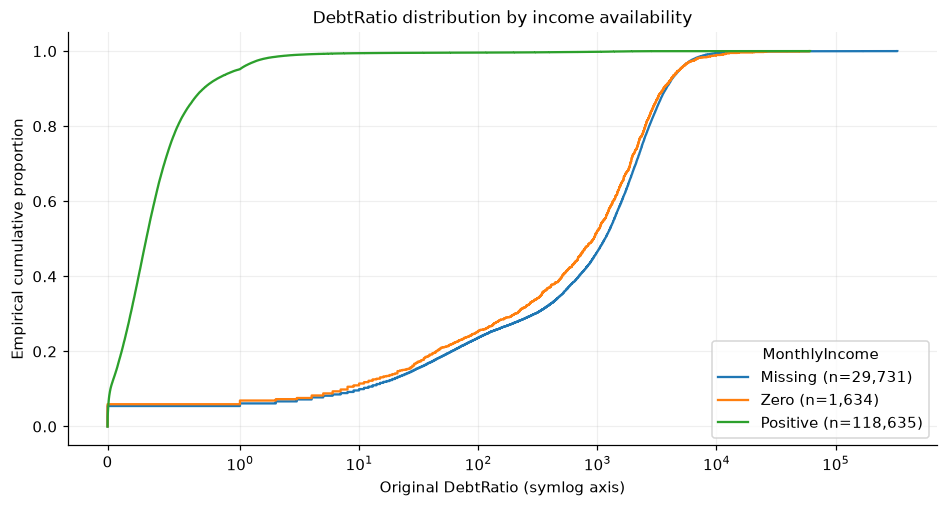

In [10]:
debt_col = 'DebtRatio'
show_table(threshold_summary(debt_col))
show_table(numeric_summary.loc[[debt_col]])
debt_rates = binned_target(debt_col, ratio_edges, ratio_labels)
show_table(debt_rates)
income = X['MonthlyIncome']
income_masks = {'Missing': income.isna(), 'Zero': income.eq(0), 'Positive': income.gt(0)}
assert sum(int(m.sum()) for m in income_masks.values()) == len(X)
debt_income_distributions = pd.DataFrame({name: X.loc[mask, debt_col].describe(percentiles=[.5, .95, .99])
    for name, mask in {'Income missing': income.isna(), 'Income present (including zero)': income.notna(),
                       'Income = 0': income.eq(0)}.items()}).T
show_table(debt_income_distributions)
debt_income_rows = []
for name, mask in income_masks.items():
    values = X.loc[mask, debt_col]
    debt_income_rows.append({'Income group': name, 'Count': len(values),
        'Median DebtRatio': values.median(), 'P99 DebtRatio': values.quantile(.99),
        'Maximum DebtRatio': values.max(),
        **{f'DebtRatio > {t} count': int(values.gt(t).sum()) for t in [1,5,10]},
        'DebtRatio > 10 (%)': values.gt(10).mean()*100})
debt_income_summary = pd.DataFrame(debt_income_rows).set_index('Income group')
show_table(debt_income_summary)
print('Ten largest original DebtRatio values:')
display(X[debt_col].nlargest(10))
fig, ax = plt.subplots(figsize=(8.5, 4.5), layout='constrained')
for name, mask in income_masks.items():
    values = X.loc[mask, debt_col].sort_values().to_numpy()
    ax.step(values, np.arange(1, len(values)+1)/len(values), where='post', label=f'{name} (n={len(values):,})')
ax.set_xscale('symlog', linthresh=1)
ax.set(title='DebtRatio distribution by income availability', xlabel='Original DebtRatio (symlog axis)', ylabel='Empirical cumulative proportion')
ax.legend(title='MonthlyIncome'); ax.grid(alpha=.2)
plt.show()


**Interpretation:** an association between extreme DebtRatio and missing/zero recorded income would warrant checking data construction and denominator handling. It does not prove how the source computed the ratio and does not justify a correction formula.

## 10. Monthly income

The dictionary says only “Monthly income”; it does not specify currency or independently identify this column as gross/net income. Zero and missing are kept distinct. Skewness is descriptive, not a rule for removing observations.


In [11]:
income_summary = mask_summary(income_masks)
show_table(income_summary)
show_table(numeric_summary.loc[['MonthlyIncome']])
print('Income skewness (nonmissing values):', income.skew())
print('Ten largest income values (currency unspecified):')
display(income.nlargest(10))
show_table(mask_summary({'Income > 100000 (inspection threshold)': income.gt(100000)}))


,Count,Events,Target rate (%)
Group,,,
Missing,29731,1669,5.6137
Zero,1634,66,4.0392
Positive,118635,8291,6.9887


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
MonthlyIncome,120269.0000,6670.2212,14384.6742,0.0000,0.0000,1300.0000,3400.0000,5400.0000,8249.0000,14587.6000,25000.0000,3008750.0000


Income skewness (nonmissing values): 114.04031794523321
Ten largest income values (currency unspecified):


73763     3008750.0
137140    1794060.0
111365    1560100.0
50640     1072500.0
122543     835040.0
123291     730483.0
93564      702500.0
96549      699530.0
119136     649587.0
37078      629000.0
Name: MonthlyIncome, dtype: float64

,Count,Events,Target rate (%)
Group,,,
Income > 100000 (inspection threshold),70,3,4.2857


## 11. Other count features

Inspect frequency distributions, largest values and non-integer/negative checks. Larger counts can be legitimate; no cap or winsorization is applied. Display thresholds are explicitly diagnostic, not validity rules.


In [12]:
COUNT_FEATURES = ['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']
show_table(numeric_summary.loc[COUNT_FEATURES])
count_checks = []
for col in COUNT_FEATURES:
    values = X[col]
    count_checks.append({'Feature': col, 'Missing': int(values.isna().sum()),
                         'Negative': int(values.lt(0).sum()),
                         'Non-integer observed values': int((values.notna() & values.mod(1).ne(0)).sum()),
                         'Maximum': values.max(), '>10': int(values.gt(10).sum()), '>50': int(values.gt(50).sum())})
    print(col, '| ten largest observed values:')
    display(values.nlargest(10))
show_table(pd.DataFrame(count_checks).set_index('Feature'))
show_table(X['NumberOfDependents'].value_counts(dropna=False).sort_index().rename('Count').to_frame())
print('Real estate loan/line count exceeds total open loans/lines:',
      int(X['NumberRealEstateLoansOrLines'].gt(X['NumberOfOpenCreditLinesAndLoans']).sum()))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4528,5.1460,0.0000,0.0000,2.0000,5.0000,8.0000,11.0000,18.0000,24.0000,58.0000
NumberRealEstateLoansOrLines,150000.0000,1.0182,1.1298,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,4.0000,54.0000
NumberOfDependents,146076.0000,0.7572,1.1151,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,20.0000


NumberOfOpenCreditLinesAndLoans | ten largest observed values:


30587     58
22683     57
137095    57
51026     56
107427    56
16537     54
54115     54
66979     54
105480    54
112934    53
Name: NumberOfOpenCreditLinesAndLoans, dtype: int64

NumberRealEstateLoansOrLines | ten largest observed values:


30587     54
104198    32
65728     29
18259     26
68909     25
103893    25
123746    25
46102     23
62192     23
31517     21
Name: NumberRealEstateLoansOrLines, dtype: int64

NumberOfDependents | ten largest observed values:


6299      20.0
128034    13.0
10618     10.0
12982     10.0
22698     10.0
39095     10.0
123911    10.0
42166      9.0
44848      9.0
122768     9.0
Name: NumberOfDependents, dtype: float64

,Missing,Negative,Non-integer observed values,Maximum,>10,>50
Feature,,,,,,
NumberOfOpenCreditLinesAndLoans,0,0,0,58.0000,43010,15
NumberRealEstateLoansOrLines,0,0,0,54.0000,94,1
NumberOfDependents,3924,0,0,20.0000,2,0


,Count
NumberOfDependents,
0.0,86902
1.0,26316
2.0,19522
3.0,9483
4.0,2862
5.0,746
6.0,158
7.0,51
8.0,24


Real estate loan/line count exceeds total open loans/lines: 0


## 12. Features versus target

Group summaries cover all predictive features. The selected fixed bins provide an interpretable exploratory view; they are not model features. Group sample sizes are shown because extreme-bin rates can be unstable. These are unadjusted associations and do not establish causal or independent predictive effects.


,Count,Events,Target rate (%)
age,,,
<=0,1,0,0.0000
"(0,17]",0,0,Missing
18-29,8820,1035,11.7347
30-44,38982,3700,9.4916
45-59,53879,3791,7.0361
60-74,36948,1271,3.4400
75-100,11357,228,2.0076
>100,13,1,7.6923


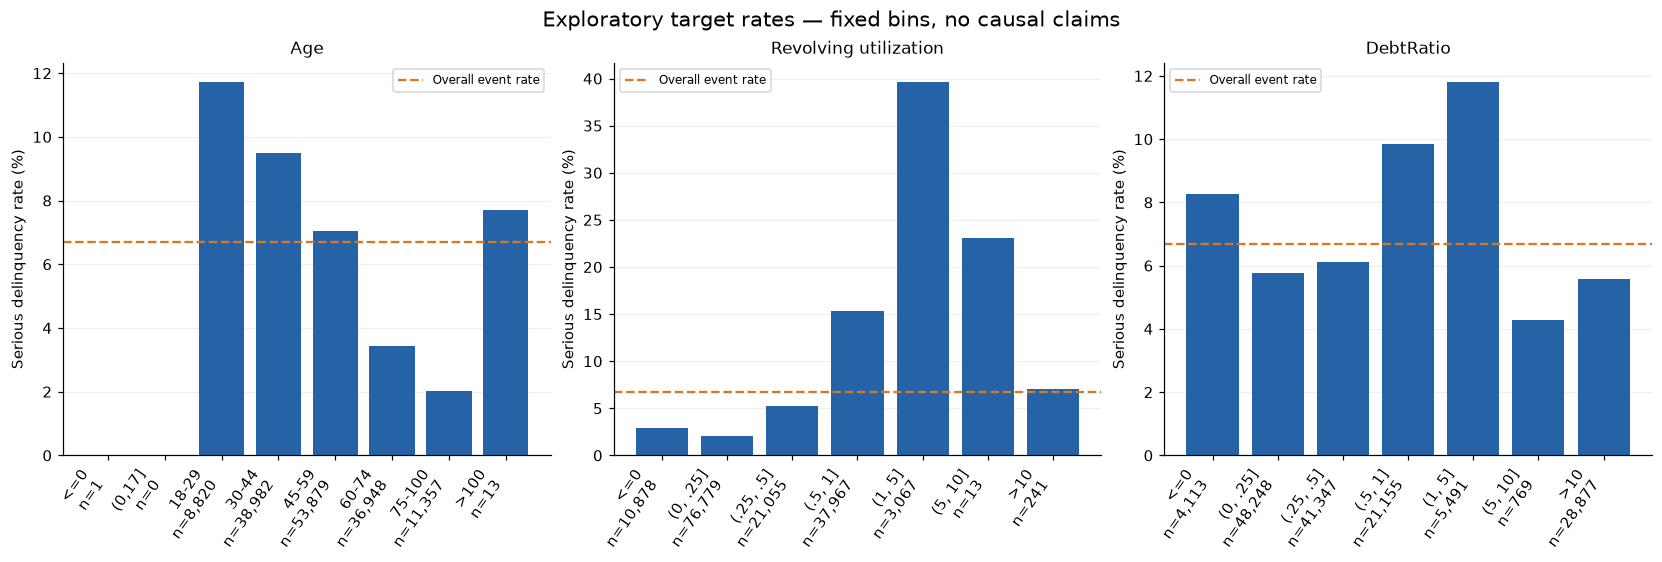

In [13]:
by_target = eda.groupby(TARGET)[FEATURES].agg(['count', 'mean', 'median']).T
show_table(by_target)
age_rates = binned_target('age', [-np.inf, 0, 17, 29, 44, 59, 74, 100, np.inf],
                         ['<=0', '(0,17]', '18-29', '30-44', '45-59', '60-74', '75-100', '>100'])
show_table(age_rates)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
for ax, table, title in zip(axes, [age_rates, utilization_rates, debt_rates], ['Age', 'Revolving utilization', 'DebtRatio']):
    bars = ax.bar(np.arange(len(table)), table['Target rate (%)'], color=BLUE)
    ax.set_xticks(np.arange(len(table)), [f'{idx}\nn={int(n):,}' for idx, n in zip(table.index,table['Count'])], rotation=55, ha='right')
    ax.axhline(y.mean()*100, color=ORANGE, linestyle='--', label='Overall event rate')
    ax.set(title=title, ylabel='Serious delinquency rate (%)')
    ax.grid(axis='y', alpha=.2)
    ax.legend(fontsize=8)
fig.suptitle('Exploratory target rates — fixed bins, no causal claims', fontsize=14)
plt.show()


## 13. Correlation

Pearson correlation is computed on the ten numerical features plus target, excluding the index. Pairwise-complete observations are used; pairs involving missing income/dependents therefore have different sample sizes. Spearman correlations are also reported for the three delinquency variables. Correlation does not imply causation and can be dominated by synchronized extremes.

A diagnostic comparison excludes rows containing 96/98 **only in a temporary correlation calculation**. The dataset is retained unchanged; this is not a cleaning decision.


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
RevolvingUtilizationOfUnsecuredLines,1.0000,-0.0059,-0.0013,0.0040,0.0071,-0.0113,-0.0011,0.0062,-0.0010,0.0016,-0.0018
age,-0.0059,1.0000,-0.0630,0.0242,0.0377,0.1477,-0.0610,0.0332,-0.0572,-0.2133,-0.1154
NumberOfTime30-59DaysPastDueNotWorse,-0.0013,-0.0630,1.0000,-0.0065,-0.0102,-0.0553,0.9836,-0.0306,0.9870,-0.0027,0.1256
DebtRatio,0.0040,0.0242,-0.0065,1.0000,-0.0287,0.0496,-0.0083,0.1200,-0.0075,-0.0407,-0.0076
MonthlyIncome,0.0071,0.0377,-0.0102,-0.0287,1.0000,0.0915,-0.0127,0.1250,-0.0111,0.0626,-0.0197
NumberOfOpenCreditLinesAndLoans,-0.0113,0.1477,-0.0553,0.0496,0.0915,1.0000,-0.0800,0.4340,-0.0711,0.0653,-0.0297
NumberOfTimes90DaysLate,-0.0011,-0.0610,0.9836,-0.0083,-0.0127,-0.0800,1.0000,-0.0452,0.9928,-0.0102,0.1172
NumberRealEstateLoansOrLines,0.0062,0.0332,-0.0306,0.1200,0.1250,0.4340,-0.0452,1.0000,-0.0397,0.1247,-0.0070
NumberOfTime60-89DaysPastDueNotWorse,-0.0010,-0.0572,0.9870,-0.0075,-0.0111,-0.0711,0.9928,-0.0397,1.0000,-0.0109,0.1023
NumberOfDependents,0.0016,-0.2133,-0.0027,-0.0407,0.0626,0.0653,-0.0102,0.1247,-0.0109,1.0000,0.0460


Pairwise sample sizes:


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
RevolvingUtilizationOfUnsecuredLines,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
age,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
NumberOfTime30-59DaysPastDueNotWorse,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
DebtRatio,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
MonthlyIncome,120269,120269,120269,120269,120269,120269,120269,120269,120269,120269,120269
NumberOfOpenCreditLinesAndLoans,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
NumberOfTimes90DaysLate,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
NumberRealEstateLoansOrLines,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
NumberOfTime60-89DaysPastDueNotWorse,150000,150000,150000,150000,120269,150000,150000,150000,150000,146076,150000
NumberOfDependents,146076,146076,146076,146076,120269,146076,146076,146076,146076,146076,146076


Delinquency Pearson, all rows:


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.9870,0.9836
NumberOfTime60-89DaysPastDueNotWorse,0.9870,1.0000,0.9928
NumberOfTimes90DaysLate,0.9836,0.9928,1.0000


Delinquency Spearman, all rows:


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.2798,0.2527
NumberOfTime60-89DaysPastDueNotWorse,0.2798,1.0000,0.3210
NumberOfTimes90DaysLate,0.2527,0.3210,1.0000


Diagnostic Pearson on rows without 96/98; observations: 149731


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.3059,0.2181
NumberOfTime60-89DaysPastDueNotWorse,0.3059,1.0000,0.2946
NumberOfTimes90DaysLate,0.2181,0.2946,1.0000


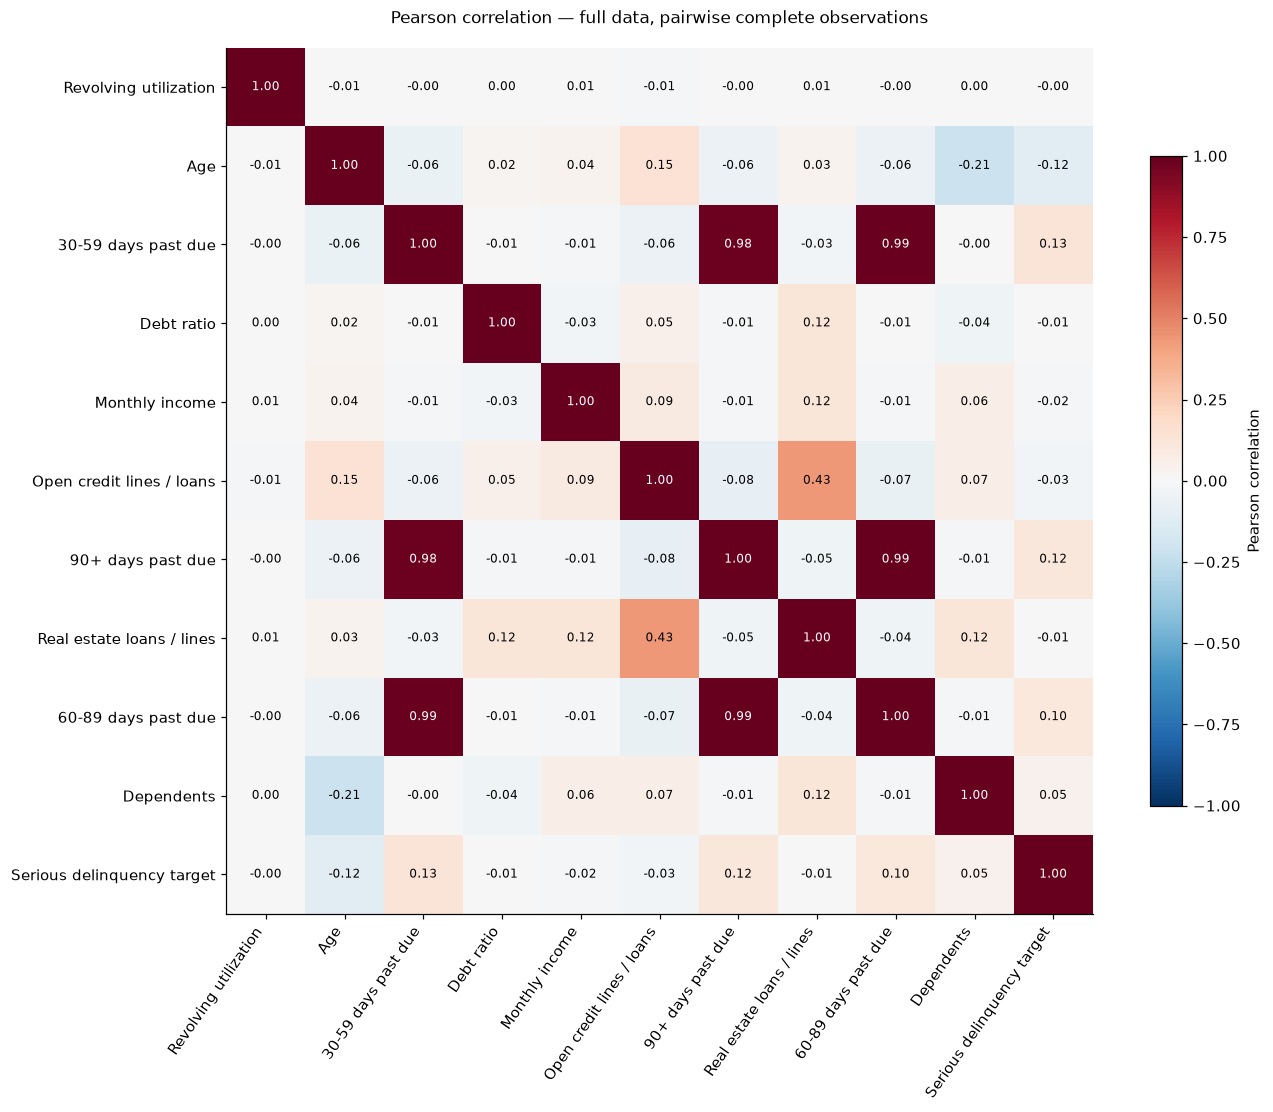

In [14]:
corr_columns = [*FEATURES, TARGET]
pearson = eda[corr_columns].corr(method='pearson')
pairwise_n = eda[corr_columns].notna().astype('int64').T.dot(eda[corr_columns].notna().astype('int64'))
show_table(pearson)
print('Pairwise sample sizes:')
show_table(pairwise_n)
spearman_delinquency = X[DELINQUENCY].corr(method='spearman')
pearson_without_special = X.loc[~any_special, DELINQUENCY].corr()
print('Delinquency Pearson, all rows:'); show_table(pearson.loc[DELINQUENCY, DELINQUENCY])
print('Delinquency Spearman, all rows:'); show_table(spearman_delinquency)
print('Diagnostic Pearson on rows without 96/98; observations:', int((~any_special).sum()))
show_table(pearson_without_special)
fig, ax = plt.subplots(figsize=(12, 10), layout='constrained')
image = ax.imshow(pearson, vmin=-1, vmax=1, cmap='RdBu_r')
plot_labels = [labels.get(c, 'Serious delinquency target') for c in corr_columns]
ax.set_xticks(range(len(corr_columns)), plot_labels, rotation=55, ha='right')
ax.set_yticks(range(len(corr_columns)), plot_labels)
for row in range(len(corr_columns)):
    for col in range(len(corr_columns)):
        value = pearson.iloc[row,col]
        ax.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(value) > .65 else 'black')
ax.set_title('Pearson correlation — full data, pairwise complete observations', pad=16)
fig.colorbar(image, ax=ax, shrink=.75, label='Pearson correlation')
fig.savefig(FIGURES_DIR / 'correlation_matrix.png', bbox_inches='tight')
plt.show()


## 14. Data quality decisions

The following table records evidence and proposed future treatments. **TO BE DECIDED** means no preprocessing/modeling policy has been implemented in this step. Excluding the index from descriptive feature calculations is not a modification of the raw dataset.


In [15]:
issues = [
    ('Index-like column', INDEX_COL, '150000 unique sequential values; absent from dictionary',
     'Potentially spurious ordering information', 'Exclude from future predictive inputs; retain source index for audit'),
    ('Class imbalance', TARGET, f'{int(y.sum()):,} events ({y.mean()*100:.3f}%)',
     'Accuracy may conceal poor minority-class performance', 'Plan stratification and appropriate metrics; compare training-only balancing later'),
    ('Missing income', 'MonthlyIncome', f'{income.isna().sum():,} missing ({income.isna().mean()*100:.3f}%)',
     'Missingness may be informative; estimator compatibility', 'Evaluate train-fitted imputation and missingness handling later'),
    ('Missing dependents', 'NumberOfDependents', f"{X['NumberOfDependents'].isna().sum():,} missing",
     'Missing is not equivalent to zero', 'Choose and validate train-fitted missing-value policy'),
    ('Duplicate feature vectors', 'All ten features',
     f'{len(repeated_features):,} repeated groups; {int(repeated_features.observations.sum()):,} observations; {len(inconsistent_groups):,} conflicting-label groups',
     'Cross-split dependence; possible optimistic evaluation', 'Investigate provenance; consider group-disjoint sensitivity analysis; do not infer borrower identity'),
    ('Zero / extreme age', 'age', f"Zero: {X['age'].eq(0).sum()}; >100: {X['age'].gt(100).sum()}; maximum: {X['age'].max()}",
     'Potential invalid entry and small-group instability', 'Investigate zero age; consider missing treatment; retain high ages absent contrary evidence'),
    ('Special values 96/98', 'Three delinquency counts', f'{int(any_special.sum())} affected observations; synchronized pattern shown above',
     'Large influence on correlations and model fit', 'Seek source explanation; compare explicitly documented treatments later'),
    ('Utilization extremes', util_col, f'Maximum {X[util_col].max():g}; >1: {X[util_col].gt(1).sum():,}',
     'Outliers and over-limit accounts may behave differently', 'Investigate units/provenance; retain >1 provisionally; decide any training-only treatment later'),
    ('DebtRatio extremes', 'DebtRatio / MonthlyIncome', f'Maximum {X[debt_col].max():g}; >10: {X[debt_col].gt(10).sum():,}',
     'Possible denominator/recording effects; skewed summaries', 'Investigate income-group patterns; do not infer total debt or recalculate ratio'),
    ('Zero / extreme income', 'MonthlyIncome', f'Zero: {income.eq(0).sum():,}; maximum: {income.max():g}',
     'Zero and missing differ; long tail affects scale-sensitive methods', 'Retain zero separately; verify source/units and decide tail policy on training data'),
    ('Extreme count features', ', '.join(COUNT_FEATURES), ', '.join(f'{labels[c]} max={X[c].max():g}' for c in COUNT_FEATURES),
     'Rare observations may dominate small-bin summaries', 'Validate plausibility; do not automatically cap or delete'),
    ('Full-data exploratory access', 'All predictors and target', 'EDA uses all 150000 labeled observations before a future split',
     'Future internal holdout is not untouched by analyst inspection', 'Freeze decisions, keep evaluation isolated, disclose limitation; prefer independent data for stronger validation')
]
quality_summary = pd.DataFrame(issues, columns=['Issue', 'Affected Feature(s)', 'Evidence', 'Potential Modeling Impact', 'Recommended Treatment'])
quality_summary['Decision Status'] = 'TO BE DECIDED'
show_table(quality_summary)


,Issue,Affected Feature(s),Evidence,Potential Modeling Impact,Recommended Treatment,Decision Status
0,Index-like column,Unnamed: 0,150000 unique sequential values; absent from dictionary,Potentially spurious ordering information,Exclude from future predictive inputs; retain source index for audit,TO BE DECIDED
1,Class imbalance,SeriousDlqin2yrs,"10,026 events (6.684%)",Accuracy may conceal poor minority-class performance,Plan stratification and appropriate metrics; compare training-only balancing later,TO BE DECIDED
2,Missing income,MonthlyIncome,"29,731 missing (19.821%)",Missingness may be informative; estimator compatibility,Evaluate train-fitted imputation and missingness handling later,TO BE DECIDED
3,Missing dependents,NumberOfDependents,"3,924 missing",Missing is not equivalent to zero,Choose and validate train-fitted missing-value policy,TO BE DECIDED
4,Duplicate feature vectors,All ten features,"354 repeated groups; 1,000 observations; 37 conflicting-label groups",Cross-split dependence; possible optimistic evaluation,Investigate provenance; consider group-disjoint sensitivity analysis; do not infer borrower identity,TO BE DECIDED
5,Zero / extreme age,age,Zero: 1; >100: 13; maximum: 109,Potential invalid entry and small-group instability,Investigate zero age; consider missing treatment; retain high ages absent contrary evidence,TO BE DECIDED
6,Special values 96/98,Three delinquency counts,269 affected observations; synchronized pattern shown above,Large influence on correlations and model fit,Seek source explanation; compare explicitly documented treatments later,TO BE DECIDED
7,Utilization extremes,RevolvingUtilizationOfUnsecuredLines,"Maximum 50708; >1: 3,321",Outliers and over-limit accounts may behave differently,Investigate units/provenance; retain >1 provisionally; decide any training-only treatment later,TO BE DECIDED
8,DebtRatio extremes,DebtRatio / MonthlyIncome,"Maximum 329664; >10: 28,877",Possible denominator/recording effects; skewed summaries,Investigate income-group patterns; do not infer total debt or recalculate ratio,TO BE DECIDED
9,Zero / extreme income,MonthlyIncome,"Zero: 1,634; maximum: 3.00875e+06",Zero and missing differ; long tail affects scale-sensitive methods,Retain zero separately; verify source/units and decide tail policy on training data,TO BE DECIDED


## Key Findings

The statements below summarize this executed notebook on the verified dataset; they are descriptive findings, not model performance claims.

| Topic | OBSERVATION | INTERPRETATION | RECOMMENDATION |
|---|---|---|---|
| Dataset and target | 150,000 observations; 10 original predictors; 10,026 events (6.684%); no missing targets. | The event is a minority class. | Preserve target meaning and predeclare suitable evaluation metrics; do not balance the full dataset. |
| Missing values | Income is missing in 29,731 rows (19.821%); dependents in 3,924 (2.616%). Event rates are 5.614% vs 6.949% for missing/present income and 4.562% vs 6.741% for missing/present dependents. | Missingness is associated with target differences, without establishing causation. | Investigate mechanisms and choose a train-fitted missingness policy later. |
| Duplicates | Including target: 609 excess rows, 351 repeated groups, 960 observations. Features only: 646 excess rows, 354 repeated groups, 1,000 observations; largest group 12. There are 37 conflicting-target groups containing 145 observations. | Identical vectors can cross splits, but do not establish shared borrower identity or justify automatic deletion. | Review provenance and predeclare a duplicate-aware split sensitivity analysis. |
| Age | One zero-age record (target 0); 13 records above 100 years (one event); maximum 109. | Zero requires validity investigation; the very-old group is too small for stable conclusions. | Investigate zero as possibly invalid/missing; retain high ages provisionally. |
| Delinquency 96/98 | All three variables simultaneously equal 96 in five rows (four events) and 98 in 264 rows (143 events). | These synchronized special values require source investigation; their meaning is undocumented. | Do not label them missing/error codes or recode automatically. |
| Utilization | 3,321 ratios exceed 1; 254 exceed 5; 241 exceed 10; maximum 50,708. Event rate is 39.680% for (1,5] and 7.054% for >10. | The association is not monotonic across the extreme tail; >1 is not automatically an error. | Validate ratio construction and consider treatment sensitivity later, without inventing unavailable components. |
| DebtRatio | Median is 1,159 for missing income, 930 for zero income and 0.292454 for positive income. DebtRatio >10 occurs in 90.044%, 88.556% and 0.555% of those groups respectively. Maximum is 329,664. | Extreme values are strongly associated with income availability; this does not prove a denominator-handling rule. | Investigate source construction; do not reinterpret as total debt/income or apply an inferred correction. |
| Income and count tails | 1,634 income values are zero; maximum income 3,008,750; skewness 114.040. Maximum open lines/loans is 58, real-estate lines/loans 54, and dependents 20. | Long tails and sparse extremes need contextual checks; currency is unspecified. | Keep zero distinct from missing, and review plausibility before any training-only treatment. |
| Correlation | Delinquency Pearson correlations are 0.984-0.993. Spearman is 0.253-0.321. Diagnostic Pearson without 96/98 rows is 0.218-0.306. | The all-row linear correlations are highly sensitive to synchronized extremes. Correlation is not causation or a feature-importance measure. | Avoid redundancy decisions based only on the full-data Pearson matrix. |
| Evaluation scope | This EDA inspected the full labeled dataset before splitting. | A later internal holdout is not untouched by analyst inspection. | Freeze decisions before modeling, isolate later evaluation, and disclose this limitation. |

All raw observations and values are retained. No recommendation in this table has been implemented as preprocessing.


## Decisions Required Before Modeling

1. **OBSERVATION:** identical feature vectors and conflicting-label groups exist. **INTERPRETATION:** they can create dependence across a random row split but do not identify people. **RECOMMENDATION:** agree on provenance checks, duplicate-group handling and a split sensitivity analysis before implementing a reproducible 70/15/15 stratified split.
2. **OBSERVATION:** income/dependents contain missing values, and zero income differs from missing income. **INTERPRETATION:** a single universal fill rule may erase meaningful distinctions. **RECOMMENDATION:** choose a documented, train-fitted missing-value policy later.
3. **OBSERVATION:** zero age, very high ages, 96/98 delinquency values and extreme ratios/counts occur. **INTERPRETATION:** unusual does not automatically mean erroneous. **RECOMMENDATION:** establish evidence-based validity/tail policies and compare alternatives without inspecting final-test performance.
4. **OBSERVATION:** the event class is uncommon. **INTERPRETATION:** discrimination, minority-class performance and probability calibration all matter. **RECOMMENDATION:** predeclare metrics and keep any future resampling inside training folds; no SMOTE has been performed here.
5. **OBSERVATION:** the full labeled dataset was inspected as requested. **INTERPRETATION:** a later random holdout has already contributed to analyst knowledge. **RECOMMENDATION:** freeze decisions, disclose this scope and seek an independent untouched labeled test set if available; do not use the unlabeled Kaggle test file for model evaluation.

All recommendations remain pending review. Temporary bins, masks and diagnostic subsets are not saved as engineered features. No model, preprocessing pipeline, split or cleaned dataset is produced.


## Validation and artifact inventory

The final cell verifies that both source files and the raw/working DataFrames retain their original contents and all 150000 observations. Only `target_distribution.png`, `missing_values.png` and `correlation_matrix.png` are saved. The other figures remain embedded in the notebook.


In [16]:
assert file_sha256(DATA_PATH) == raw_hash_before
assert file_sha256(DICTIONARY_PATH) == dictionary_hash_before
assert frame_fingerprint(raw) == raw_fingerprint_before
assert frame_fingerprint(eda) == eda_fingerprint_before
assert len(raw) == len(eda) == len(X) == len(y) == 150000
assert list(eda.columns) == declared_columns
assert quality_summary['Decision Status'].eq('TO BE DECIDED').all()
for filename in ['target_distribution.png', 'missing_values.png', 'correlation_matrix.png']:
    assert (FIGURES_DIR / filename).is_file()
print('PASS: source hashes and raw/working DataFrame fingerprints unchanged.')
print('PASS: 150000 observations retained; ten original predictive features; no model or split.')
print('PASS: three portfolio figures saved; all treatment decisions pending review.')

# Compact verification evidence for the execution report; this is not a new dataset.
audit = {
    'versions': versions, 'shape': list(raw.shape),
    'target_counts': target_summary['Count'].to_dict(),
    'missing_association': missing_association.reset_index().to_dict('records'),
    'duplicates': duplicate_summary.reset_index().to_dict('records'),
    'inconsistent_groups': len(inconsistent_groups),
    'inconsistent_observations': int(inconsistent_groups['observations'].sum()),
    'age': age_summary.reset_index().to_dict('records'),
    'special': special_summary.reset_index().to_dict('records'),
    'special_patterns': special_patterns.reset_index().to_dict('records'),
    'utilization_thresholds': threshold_summary(util_col).reset_index().to_dict('records'),
    'utilization_rates': utilization_rates.reset_index().to_dict('records'),
    'debt_thresholds': threshold_summary(debt_col).reset_index().to_dict('records'),
    'debt_income': debt_income_summary.reset_index().to_dict('records'),
    'debt_income_distributions': debt_income_distributions.reset_index().to_dict('records'),
    'income_groups': income_summary.reset_index().to_dict('records'), 'income_skewness': float(income.skew()),
    'delinquency_pearson': pearson.loc[DELINQUENCY, DELINQUENCY].to_dict(),
    'delinquency_spearman': spearman_delinquency.to_dict(),
    'delinquency_pearson_without_special': pearson_without_special.to_dict(),
    'target_pearson': pearson[TARGET].drop(TARGET).to_dict(),
    'raw_sha256': raw_hash_before, 'quality_issue_count': len(quality_summary)}


PASS: source hashes and raw/working DataFrame fingerprints unchanged.
PASS: 150000 observations retained; ten original predictive features; no model or split.
PASS: three portfolio figures saved; all treatment decisions pending review.
